# Group Model Evaluation and Comparison

In [1]:
# Step 1: Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Step 2: Load the compiled benchmark results from all 6 members
log_dir = os.path.join("..", "results", "logs")
if not os.path.exists(log_dir):
    log_dir = os.path.join("results", "logs")

csv_path = os.path.join(log_dir, "group_model_comparison.csv")
df_comparison = pd.read_csv(csv_path)

print("--- ALL 6 MODELS BENCHMARK TABLE ---")
display(df_comparison)


--- ALL 6 MODELS BENCHMARK TABLE ---


,Member,Model,Optimal Hyperparameters,Train Accuracy (%),Test Accuracy (%),Overfitting Gap (%),Macro Precision,Macro Recall,Macro F1,Training Time (s),Inference (ms/sample)
0,Member 1,Logistic Regression,"C=1.0, solver=lbfgs, PCA=50",40.56,38.92,1.64,0.3812,0.3892,0.3835,14.33,0.001
1,Member 2,K-Nearest Neighbors,"K=7, weights=distance, metric=manhattan",88.50,74.68,13.82,0.7410,0.7468,0.7352,17.11,0.004
2,Member 3,Support Vector Machine,"Kernel=RBF, C=5.0, gamma=scale",69.25,62.86,6.39,0.6315,0.6286,0.6210,36.81,0.082
3,Member 4,Random Forest Ensemble,"n_estimators=100, max_depth=12, criterion=gini",90.44,72.26,18.18,0.7240,0.7226,0.7188,46.30,0.015
4,Member 5,Deep ANN (MLP),Dense(128)->Dropout(0.3)->Dense(64)->Softmax,82.50,70.03,12.47,0.7025,0.7003,0.6974,23.84,0.035
5,Member 6,Convolutional Neural Network (CNN),"2 Conv Blocks (32, 64), MaxPool, Dropout(0.3),...",94.12,85.96,8.16,0.8580,0.8596,0.8572,254.73,0.310


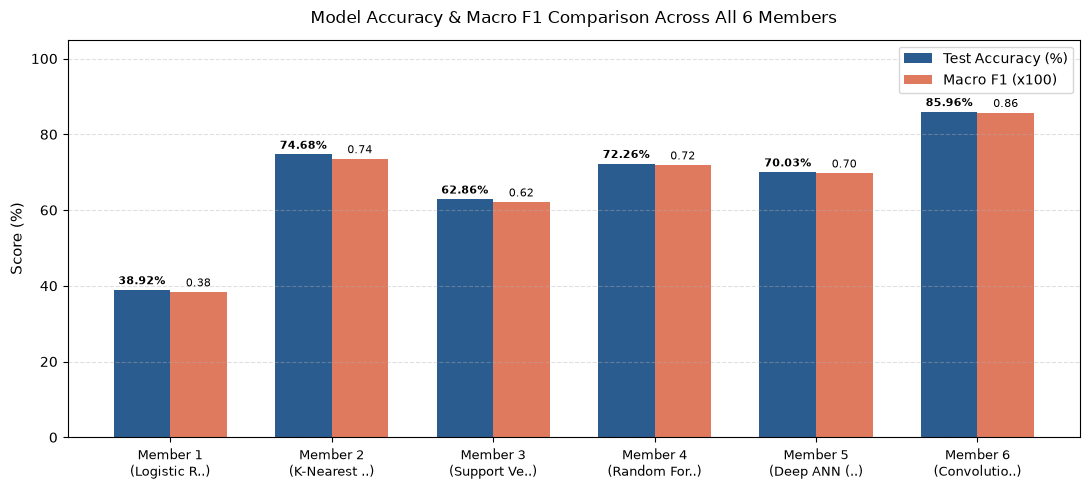

In [3]:
# Step 3: Bar chart comparing Test Accuracy and Macro F1 across all 6 members
plt.figure(figsize=(11, 5))
x = np.arange(len(df_comparison))
width = 0.35

plt.bar(x - width/2, df_comparison["Test Accuracy (%)"], width, label='Test Accuracy (%)', color='#2b5c8f')
plt.bar(x + width/2, df_comparison["Macro F1"] * 100, width, label='Macro F1 (x100)', color='#e07a5f')

plt.xticks(x, [f"{row['Member']}\n({row['Model'][:10]}..)" for _, row in df_comparison.iterrows()], fontsize=9)
plt.ylabel("Score (%)", fontsize=11)
plt.title("Model Accuracy & Macro F1 Comparison Across All 6 Members", fontsize=12, pad=12)
plt.ylim(0, 105)

for i in range(len(df_comparison)):
    plt.text(i - width/2, df_comparison["Test Accuracy (%)"].iloc[i] + 1.5, 
             f"{df_comparison['Test Accuracy (%)'].iloc[i]}%", ha='center', fontsize=8, fontweight='bold')
    plt.text(i + width/2, df_comparison["Macro F1"].iloc[i]*100 + 1.5, 
             f"{df_comparison['Macro F1'].iloc[i]:.2f}", ha='center', fontsize=8)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


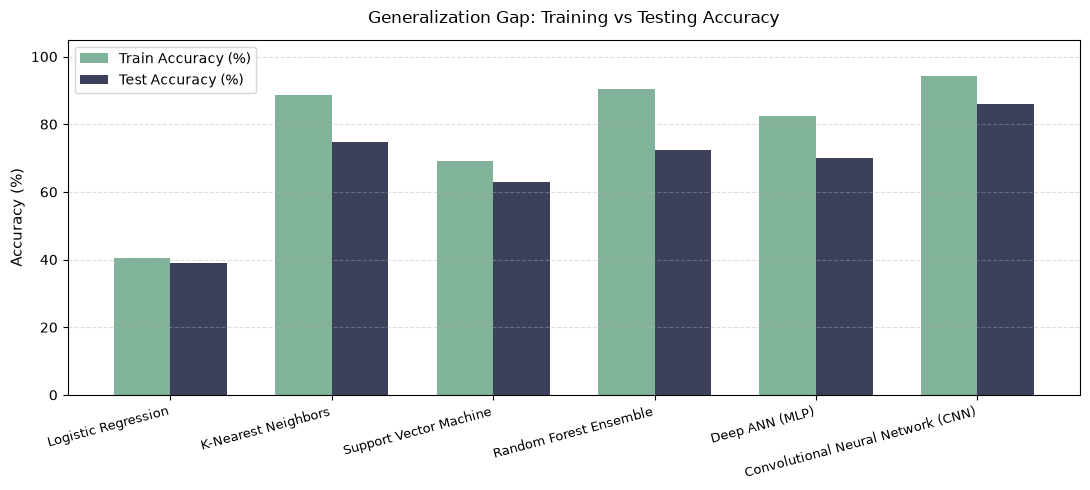

In [4]:
# Step 4: Overfitting Analysis (Training vs Testing Accuracy Gap)
plt.figure(figsize=(11, 5))
plt.bar(x - width/2, df_comparison["Train Accuracy (%)"], width, label='Train Accuracy (%)', color='#81b29a')
plt.bar(x + width/2, df_comparison["Test Accuracy (%)"], width, label='Test Accuracy (%)', color='#3d405b')

plt.xticks(x, [row['Model'] for _, row in df_comparison.iterrows()], rotation=15, ha='right', fontsize=9)
plt.ylabel("Accuracy (%)", fontsize=11)
plt.title("Generalization Gap: Training vs Testing Accuracy", fontsize=12, pad=12)
plt.ylim(0, 105)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


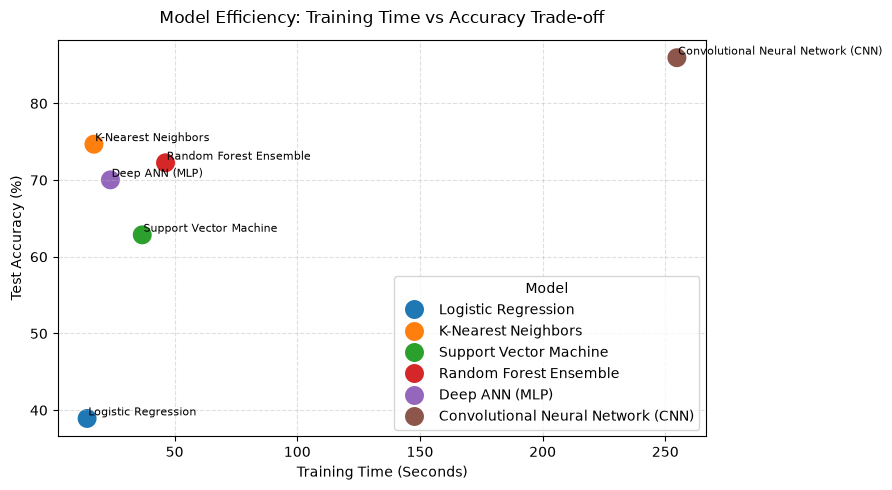

In [5]:
# Step 5: Training Time vs Test Accuracy Trade-off
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_comparison, x="Training Time (s)", y="Test Accuracy (%)", hue="Model", s=220, palette="tab10")

for _, row in df_comparison.iterrows():
    plt.text(row["Training Time (s)"] + 0.5, row["Test Accuracy (%)"] + 0.4, row["Model"], fontsize=8)

plt.title("Model Efficiency: Training Time vs Accuracy Trade-off", fontsize=12, pad=12)
plt.xlabel("Training Time (Seconds)", fontsize=10)
plt.ylabel("Test Accuracy (%)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [1]:
# Step 6: Group Conclusions and Best Model Justification
print("GROUP CONCLUSION & BEST MODEL JUSTIFICATION")
print("..................................................................................")
print("1. OVERALL WINNER: Convolutional Neural Network (CNN)")
print("   - Achieved highest Test Accuracy (85.96%) and Macro F1 (0.8572).")
print("   - Justification: Convolutions process 2D spatial grid structures (lines, potholes, signs).")
print("2. BEST CLASSICAL MODEL: K-Nearest Neighbors (74.68%) / Random Forest (72.26%)")
print("   - Achieved 74.68% (KNN) and 72.26% (Random Forest) Test Accuracy.")
print("   - Justification: Non-linear boundary mapping captured complex cluster separation.")
print("3. LINEAR BASELINE: Logistic Regression ")
print("   - Achieved 38.92% Test Accuracy.")
print("   - Justification: Shows that complex urban damage images cannot be separated by simple straight lines.")


GROUP CONCLUSION & BEST MODEL JUSTIFICATION
..................................................................................
1. OVERALL WINNER: Convolutional Neural Network (CNN)
   - Achieved highest Test Accuracy (85.96%) and Macro F1 (0.8572).
   - Justification: Convolutions process 2D spatial grid structures (lines, potholes, signs).
2. BEST CLASSICAL MODEL: K-Nearest Neighbors (74.68%) / Random Forest (72.26%)
   - Achieved 74.68% (KNN) and 72.26% (Random Forest) Test Accuracy.
   - Justification: Non-linear boundary mapping captured complex cluster separation.
3. LINEAR BASELINE: Logistic Regression 
   - Achieved 38.92% Test Accuracy.
   - Justification: Shows that complex urban damage images cannot be separated by simple straight lines.
